# Spotter Freight Rate Prediction — Exploratory Data Analysis

## Objective

Explore the provided freight load dataset to understand:

- Dataset structure
- Feature types
- Missing values
- Duplicate records
- Target variable distribution
- Numerical relationships
- Categorical variables
- Temporal patterns
- Potential data leakage
- Considerations for model validation

In [279]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [280]:
df = pd.read_csv("../data/train-test.csv")
df.head()

,load_id,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,equipment,weight,date,market_index,quote_signal,posted_rate
0,TR-000001,Richmond,Baltimore,38.09122,-76.78906,38.16908,-72.74564,274.3,Dry Van,30658.0,2025-01-01,0.95684,2.39595,645.41
1,TR-000002,Richmond,Philadelphia,38.09122,-76.78906,39.22317,-72.96710,280.5,Reefer,17555.0,2025-01-01,0.97623,2.43355,679.97
2,TR-000003,Philadelphia,Green Bay,39.22317,-72.96710,44.30296,-87.52871,967.8,Dry Van,31721.0,2025-01-01,1.00971,1.84491,1802.54
3,TR-000004,Hartford,Atlanta,39.55328,-72.18051,34.84933,-86.28940,965.4,Dry Van,32333.0,2025-01-01,0.94518,1.87712,1827.28
4,TR-000005,Dallas,Nashville,31.83025,-94.38343,35.29479,-88.08915,541.9,Reefer,35183.0,2025-01-01,0.98480,2.56300,1380.28


In [281]:
print("Shape:", df.shape)
print("\nData types and non-null counts:")
df.info()

Shape: (48000, 14)

Data types and non-null counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48000 entries, 0 to 47999
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   load_id       48000 non-null  object 
 1   pickup        48000 non-null  object 
 2   delivery      48000 non-null  object 
 3   pickup_lat    48000 non-null  float64
 4   pickup_lon    48000 non-null  float64
 5   delivery_lat  48000 non-null  float64
 6   delivery_lon  48000 non-null  float64
 7   distance      48000 non-null  float64
 8   equipment     48000 non-null  object 
 9   weight        47700 non-null  float64
 10  date          48000 non-null  object 
 11  market_index  47626 non-null  float64
 12  quote_signal  48000 non-null  float64
 13  posted_rate   48000 non-null  float64
dtypes: float64(9), object(5)
memory usage: 5.1+ MB


In [282]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
load_id           0
pickup            0
delivery          0
pickup_lat        0
pickup_lon        0
delivery_lat      0
delivery_lon      0
distance          0
equipment         0
weight          300
date              0
market_index    374
quote_signal      0
posted_rate       0
dtype: int64


In [283]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
load_id           0
pickup            0
delivery          0
pickup_lat        0
pickup_lon        0
delivery_lat      0
delivery_lon      0
distance          0
equipment         0
weight          300
date              0
market_index    374
quote_signal      0
posted_rate       0
dtype: int64


In [284]:
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate load IDs:", df["load_id"].duplicated().sum())

Duplicate rows: 0
Duplicate load IDs: 0


In [285]:
print("First date is ", df["date"].min()) 
print("Last date is ", df["date"].max()) 

First date is  2025-01-01
Last date is  2025-10-31


In [286]:
print("Number of unique dates:", df["date"].nunique())


Number of unique dates: 304


In [287]:
print(df["date"].value_counts().sort_index().head(10))


date
2025-01-01    145
2025-01-02    168
2025-01-03    156
2025-01-04    156
2025-01-05    154
2025-01-06    168
2025-01-07    161
2025-01-08    189
2025-01-09    148
2025-01-10    173
Name: count, dtype: int64


In [288]:
df.describe()   

,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,weight,market_index,quote_signal,posted_rate
count,48000.000000,48000.000000,48000.000000,48000.000000,48000.000000,47700.000000,47626.000000,48000.000000,48000.000000
mean,35.647545,-90.928964,35.641175,-90.857310,1135.856654,31028.844004,1.083387,2.062468,2373.980682
std,4.315285,13.482431,4.317199,13.476589,728.564416,9391.440620,0.168091,0.291391,1486.493245
min,28.357650,-121.698490,28.357650,-121.698490,70.000000,-47500.000000,0.676390,0.692280,57.220000
25%,31.986910,-98.400590,31.986910,-98.400590,550.400000,25800.000000,0.949670,1.891030,1251.555000
50%,35.294790,-88.089150,35.294790,-87.528710,953.300000,31436.500000,1.055800,2.055750,2030.760000
75%,39.411040,-83.285060,39.411040,-83.285060,1645.525000,37018.000000,1.219590,2.221685,3330.750000
max,44.302960,-69.500000,44.302960,-69.500000,3439.800000,47500.000000,1.467780,3.610350,25533.000000


In [289]:
df[[
    "distance",
    "weight",
    "market_index",
    "quote_signal",
    "posted_rate"
]].describe()

,distance,weight,market_index,quote_signal,posted_rate
count,48000.000000,47700.000000,47626.000000,48000.000000,48000.000000
mean,1135.856654,31028.844004,1.083387,2.062468,2373.980682
std,728.564416,9391.440620,0.168091,0.291391,1486.493245
min,70.000000,-47500.000000,0.676390,0.692280,57.220000
25%,550.400000,25800.000000,0.949670,1.891030,1251.555000
50%,953.300000,31436.500000,1.055800,2.055750,2030.760000
75%,1645.525000,37018.000000,1.219590,2.221685,3330.750000
max,3439.800000,47500.000000,1.467780,3.610350,25533.000000


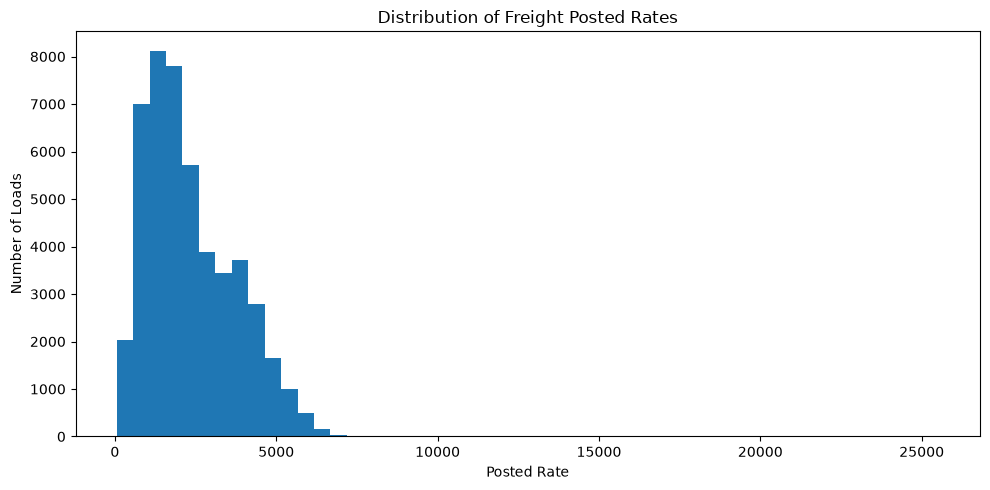

In [290]:
plt.figure(figsize=(10, 5))

plt.hist(df["posted_rate"], bins=50)

plt.xlabel("Posted Rate")
plt.ylabel("Number of Loads")
plt.title("Distribution of Freight Posted Rates")

plt.tight_layout()
plt.show()

In [291]:
df[df["weight"] < 0][["load_id", "weight", "distance", "equipment", "posted_rate"]].head(20)

,load_id,weight,distance,equipment,posted_rate
68,TR-000069,-36559.0,1334.2,Reefer,2831.27
204,TR-000205,-26670.0,496.2,Dry Van,1046.92
206,TR-000207,-20003.0,411.3,Reefer,959.15
225,TR-000226,-23981.0,1317.4,Reefer,2836.00
376,TR-000377,-41397.0,1331.1,Dry Van,2522.54
446,TR-000447,-37215.0,2438.3,Reefer,4841.57
495,TR-000496,-31214.0,715.9,Dry Van,1473.78
641,TR-000642,-41023.0,582.4,Dry Van,1264.33
806,TR-000807,-28320.0,676.1,Dry Van,1307.76
1093,TR-001094,-25153.0,1058.5,Dry Van,1907.83


In [292]:
print("Negative weights:", (df["weight"] < 0).sum())

Negative weights: 292


In [293]:
df.loc[df["weight"] < 0, "weight"].describe()

count      292.000000
mean    -31724.195205
std       8262.536326
min     -47500.000000
25%     -37284.250000
50%     -31821.500000
75%     -25928.500000
max      -5000.000000
Name: weight, dtype: float64

In [294]:
df[df["weight"] < 0]["weight"].value_counts().sort_index()

weight
-47500.0    13
-46334.0     1
-46187.0     1
-45975.0     1
-45588.0     1
            ..
-13852.0     1
-13119.0     1
-12836.0     1
-11574.0     1
-5000.0      1
Name: count, Length: 275, dtype: int64

In [295]:
df.groupby(df["weight"] < 0)["posted_rate"].describe()

,count,mean,std,min,25%,50%,75%,max
weight,,,,,,,,
False,47708.0,2373.883943,1485.511426,57.22,1251.555,2031.16,3331.2250,25533.00
True,292.0,2389.786233,1641.761285,247.37,1257.410,1994.96,3185.2575,14561.21


In [296]:
df.groupby(df["weight"]< 0)["distance"].mean()

weight
False    1135.948074
True     1120.920205
Name: distance, dtype: float64

In [297]:
df.groupby(df["weight"] < 0)["quote_signal"].mean()

weight
False    2.062593
True     2.041966
Name: quote_signal, dtype: float64

In [298]:
df.groupby(df["weight"] < 0)["quote_signal"].mean()

weight
False    2.062593
True     2.041966
Name: quote_signal, dtype: float64

In [299]:
df[df["weight"] < 0][
    [
        "load_id",
        "pickup",
        "delivery",
        "distance",
        "equipment",
        "weight",
        "market_index",
        "quote_signal",
        "posted_rate"
    ]
].head(20)

,load_id,pickup,delivery,distance,equipment,weight,market_index,quote_signal,posted_rate
68,TR-000069,Amarillo,Dayton,1334.2,Reefer,-36559.0,0.96102,2.11777,2831.27
204,TR-000205,Fresno,Tucson,496.2,Dry Van,-26670.0,0.96903,2.13155,1046.92
206,TR-000207,Columbia,Raleigh,411.3,Reefer,-20003.0,0.94800,2.31682,959.15
225,TR-000226,Greensboro,Lubbock,1317.4,Reefer,-23981.0,1.00820,2.13918,2836.00
376,TR-000377,Madison,Providence,1331.1,Dry Van,-41397.0,0.94787,1.91867,2522.54
446,TR-000447,Albuquerque,Albany,2438.3,Reefer,-37215.0,0.96575,1.96959,4841.57
495,TR-000496,Montgomery,Dayton,715.9,Dry Van,-31214.0,0.85153,2.03947,1473.78
641,TR-000642,Tulsa,Indianapolis,582.4,Dry Van,-41023.0,0.81988,2.22721,1264.33
806,TR-000807,Cincinnati,Buffalo,676.1,Dry Van,-28320.0,0.79158,1.95680,1307.76
1093,TR-001094,Cincinnati,Albany,1058.5,Dry Van,-25153.0,0.89891,1.81081,1907.83


In [300]:
# 1. Sanity check
print("Missing weights:", df["weight"].isna().sum())
print("Negative weights:", (df["weight"] < 0).sum())
print("Valid weights:", (df["weight"] >= 0).sum())

Missing weights: 300
Negative weights: 292
Valid weights: 47408


In [301]:
# 2. Target comparison
df.groupby(df["weight"] < 0)["posted_rate"].describe()

,count,mean,std,min,25%,50%,75%,max
weight,,,,,,,,
False,47708.0,2373.883943,1485.511426,57.22,1251.555,2031.16,3331.2250,25533.00
True,292.0,2389.786233,1641.761285,247.37,1257.410,1994.96,3185.2575,14561.21


In [302]:
# Comparing the mean of other features for negative vs valid weights
print("Distance:")
print(df.groupby(df["weight"] < 0)["distance"].mean())

print("\nQuote signal:")
print(df.groupby(df["weight"] < 0)["quote_signal"].mean())

print("\nMarket index:")
print(df.groupby(df["weight"] < 0)["market_index"].mean())

Distance:
weight
False    1135.948074
True     1120.920205
Name: distance, dtype: float64

Quote signal:
weight
False    2.062593
True     2.041966
Name: quote_signal, dtype: float64

Market index:
weight
False    1.083308
True     1.096322
Name: market_index, dtype: float64


In [303]:
# 4. Inspect negative-weight records
df[df["weight"] < 0][
    ["load_id", "pickup", "delivery", "distance",
     "equipment", "weight", "market_index",
     "quote_signal", "posted_rate"]
].head(20)

,load_id,pickup,delivery,distance,equipment,weight,market_index,quote_signal,posted_rate
68,TR-000069,Amarillo,Dayton,1334.2,Reefer,-36559.0,0.96102,2.11777,2831.27
204,TR-000205,Fresno,Tucson,496.2,Dry Van,-26670.0,0.96903,2.13155,1046.92
206,TR-000207,Columbia,Raleigh,411.3,Reefer,-20003.0,0.94800,2.31682,959.15
225,TR-000226,Greensboro,Lubbock,1317.4,Reefer,-23981.0,1.00820,2.13918,2836.00
376,TR-000377,Madison,Providence,1331.1,Dry Van,-41397.0,0.94787,1.91867,2522.54
446,TR-000447,Albuquerque,Albany,2438.3,Reefer,-37215.0,0.96575,1.96959,4841.57
495,TR-000496,Montgomery,Dayton,715.9,Dry Van,-31214.0,0.85153,2.03947,1473.78
641,TR-000642,Tulsa,Indianapolis,582.4,Dry Van,-41023.0,0.81988,2.22721,1264.33
806,TR-000807,Cincinnati,Buffalo,676.1,Dry Van,-28320.0,0.79158,1.95680,1307.76
1093,TR-001094,Cincinnati,Albany,1058.5,Dry Van,-25153.0,0.89891,1.81081,1907.83


In [304]:
pd.crosstab(
    df["equipment"],
    df["weight"] < 0,
    normalize="index"
)

weight,False,True
equipment,,
Dry Van,0.994302,0.005698
Flatbed,0.992003,0.007997
Reefer,0.994438,0.005562


In [305]:
pd.crosstab(
    df["equipment"],
    df["weight"].isna(),
    normalize="index"
)

weight,False,True
equipment,,
Dry Van,0.993567,0.006433
Flatbed,0.993716,0.006284
Reefer,0.994188,0.005812


In [306]:
df.groupby("equipment")["weight"].describe()

,count,mean,std,min,25%,50%,75%,max
equipment,,,,,,,,
Dry Van,27027.0,31027.293447,9316.603583,-47500.0,25768.00,31373.0,36972.0,47500.0
Flatbed,8698.0,30963.625776,9809.033471,-47500.0,25830.25,31462.5,37053.0,47500.0
Reefer,11975.0,31079.714572,9249.030167,-47500.0,25845.00,31524.0,37078.0,47500.0


In [307]:
df_clean = df.copy()

df_clean.loc[df_clean["weight"] < 0, "weight"] = np.nan     

In [308]:
print("Original rows:", len(df))
print("Missing weights after cleaning:", df_clean["weight"].isna().sum())
print("Negative weights after cleaning:", (df_clean["weight"] < 0).sum())

Original rows: 48000
Missing weights after cleaning: 592
Negative weights after cleaning: 0


In [309]:
df_clean[[
    "distance",
    "weight",
    "market_index",
    "quote_signal",
    "posted_rate"
]].corr()


,distance,weight,market_index,quote_signal,posted_rate
distance,1.000000,0.001946,-0.002181,-0.057244,0.908519
weight,0.001946,1.000000,0.002396,0.006198,0.041674
market_index,-0.002181,0.002396,1.000000,-0.067827,0.034165
quote_signal,-0.057244,0.006198,-0.067827,1.000000,-0.039858
posted_rate,0.908519,0.041674,0.034165,-0.039858,1.000000


In [310]:
df_clean.groupby("equipment")["weight"].median()

equipment
Dry Van    31442.5
Flatbed    31525.0
Reefer     31576.5
Name: weight, dtype: float64

In [311]:
df_clean["weight"].median()
weight_median = df_clean["weight"].median()
df_clean["weight"] = df_clean["weight"].fillna(weight_median)

In [312]:
print("Missing weights:", df_clean["weight"].isna().sum())
print("Negative weights:", (df_clean["weight"] < 0).sum())

Missing weights: 0
Negative weights: 0


In [313]:
df_clean["market_index"].describe()

count    47626.000000
mean         1.083387
std          0.168091
min          0.676390
25%          0.949670
50%          1.055800
75%          1.219590
max          1.467780
Name: market_index, dtype: float64

In [314]:
df_clean[df_clean["market_index"].isna()]["posted_rate"].describe()

count     374.000000
mean     2392.115107
std      1434.640755
min       207.710000
25%      1254.287500
50%      2081.100000
75%      3294.790000
max      9454.940000
Name: posted_rate, dtype: float64

In [315]:
df_clean.groupby(df_clean["market_index"].isna())["posted_rate"].mean()

market_index
False    2373.838275
True     2392.115107
Name: posted_rate, dtype: float64

In [316]:
df_clean.groupby(df_clean["market_index"].isna())["posted_rate"].mean()

market_index
False    2373.838275
True     2392.115107
Name: posted_rate, dtype: float64

In [317]:
df_clean[[
    "distance",
    "weight",
    "market_index",
    "quote_signal",
    "posted_rate"
]].corr()["posted_rate"].sort_values(ascending=False)

posted_rate     1.000000
distance        0.908519
weight          0.041405
market_index    0.034165
quote_signal   -0.039858
Name: posted_rate, dtype: float64

In [318]:
market_median = df_clean["market_index"].median()

df_clean["market_index"] = df_clean["market_index"].fillna(market_median)

In [319]:
market_median = df_clean["market_index"].median()

df_clean["market_index"] = df_clean["market_index"].fillna(market_median)

In [320]:
print("Unique pickup locations:", df_clean["pickup"].nunique())
print("Unique delivery locations:", df_clean["delivery"].nunique())
print("Unique equipment types:", df_clean["equipment"].nunique())

Unique pickup locations: 64
Unique delivery locations: 64
Unique equipment types: 3


In [321]:
df_clean["equipment"].value_counts()

equipment
Dry Van    27202
Reefer     12045
Flatbed     8753
Name: count, dtype: int64

In [322]:
df_clean.groupby("equipment")["posted_rate"].agg(
    ["count", "mean", "median", "std"]
).sort_values("mean", ascending=False)

,count,mean,median,std
equipment,,,,
Reefer,12045,2553.636939,2196.670,1589.670824
Flatbed,8753,2445.087223,2076.810,1505.053087
Dry Van,27202,2271.548686,1953.035,1423.029914


In [323]:
df_clean["pickup"].value_counts().head(15)

pickup
Oklahoma City    1242
Lexington        1209
Bakersfield      1193
Fort Wayne       1170
Hartford         1150
Richmond         1140
Nashville        1124
Phoenix          1121
Baton Rouge      1115
Mobile           1094
Cincinnati       1080
Shreveport       1062
Kansas City      1053
Columbia         1049
Atlanta          1029
Name: count, dtype: int64

In [324]:
df_clean["delivery"].value_counts().head(15)

delivery
Lexington        1197
Fort Wayne       1176
Baton Rouge      1167
Bakersfield      1156
Hartford         1143
Oklahoma City    1140
Richmond         1109
Atlanta          1096
Phoenix          1090
Mobile           1089
Cincinnati       1084
Columbia         1071
Nashville        1064
Tucson            997
Shreveport        983
Name: count, dtype: int64

In [325]:
df_clean.groupby("pickup")["posted_rate"].mean().sort_values(
    ascending=False
).head(15)

pickup
San Francisco     4071.207108
Fresno            3878.910000
Reno              3765.391199
Phoenix           3764.774764
Los Angeles       3729.638392
Bakersfield       3519.365448
Tucson            3310.996271
Las Vegas         3292.821913
Salt Lake City    3144.764112
Providence        3134.073624
El Paso           3110.560078
Albany            2983.327879
Boston            2953.644677
Albuquerque       2871.875439
Baltimore         2740.633368
Name: posted_rate, dtype: float64

In [ ]:
df_clean.groupby("delivery")["posted_rate"].mean().sort_values(
    ascending=False
).head(15)